<a href="https://colab.research.google.com/github/tsubasa-iino/psi4book/blob/main/compchem_book_ch12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 12章 励起状態の性質を計算をしてみよう

### 環境構築

#### Google Colab上にPsi4をインストール

In [1]:
!pip install -q condacolab
import condacolab
import os

# バグ回避パッチ
if "LD_LIBRARY_PATH" not in os.environ:
    os.environ["LD_LIBRARY_PATH"] = ""

print("Installing CondaColab (Base)...")
condacolab.install()

Installing CondaColab (Base)...
⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...


ランタイム｜セッションを再起動する｜はい を実行。

In [ ]:
import condacolab
import os
import sys

condacolab.check()

# 1. 邪魔なPinningを削除
if os.path.exists("/usr/local/conda-meta/pinned"):
    !rm /usr/local/conda-meta/pinned

# 2. Python 3.12 と Psi4 をインストール（ディスク書き換え）
print("Upgrading Python to 3.12 & Installing Psi4...")
!mamba install -y -q python=3.12 psi4 -c conda-forge/label/libint_dev -c conda-forge

# 3. Pinningの復元（成功環境の再現）
os.makedirs("/usr/local/conda-meta", exist_ok=True)
with open("/usr/local/conda-meta/pinned", "w") as f:
    f.write("python 3.12.*\n")

# 4. 【最重要】カーネルの自殺（強制再起動）
# これにより、メモリ上のPython 3.11を殺し、ディスク上のPython 3.12をロードさせます
print("\n🔄 RESTARTING KERNEL TO LOAD PYTHON 3.12...")
import time
time.sleep(1)
os.kill(os.getpid(), 9)

✨🍰✨ Everything looks OK!
Upgrading Python to 3.12 & Installing Psi4...
Preparing transaction: ...working... done
Verifying transaction: ...working... done
Executing transaction: ...working... done

🔄 RESTARTING KERNEL TO LOAD PYTHON 3.12...


ランタイム｜セッションを再起動する｜はい を実行。

In [1]:
import sys
import os

# パスが通っていなければ通す
target_path = "/usr/local/lib/python3.12/site-packages"
if target_path not in sys.path:
    sys.path.insert(0, target_path)

import psi4
print(f"✅ Restart Successful.")
print(f"Psi4 Version: {psi4.__version__}")
print(f"Python Version: {sys.version.split()[0]}") # ここが3.12になっているはず

# 計算テスト
psi4.set_memory('500 MB')
mol = psi4.geometry("O\nH 1 0.96\nH 1 0.96 2 104.5")
en = psi4.energy('scf/cc-pvdz')
print(f"Energy: {en:.6f}")

✅ Restart Successful.
Psi4 Version: 1.10
Python Version: 3.12.12
Energy: -76.026633


ここまででインストール確認完了。

In [2]:
import os
import datetime
import numpy as np
import pandas as pd
import psi4

print(f'current time: {datetime.datetime.now()}')
print(f'python version:\n{sys.version}')
print(f'numpy version: {np.__version__}')
print(f'pandas version: {pd.__version__}')
print(f'psi4 version: {psi4.__version__}')

current time: 2026-01-31 05:08:16.551011
python version:
3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
numpy version: 2.0.2
pandas version: 2.2.2
psi4 version: 1.10


#### 必要なライブラリと関数の定義

In [3]:
!pip install py3Dmol
import py3Dmol

In [4]:
def show_3D(mol: psi4.core.Molecule) -> py3Dmol.view:
    """
    Psi4のMoleculeオブジェクトをpy3Dmolで描画する
    Args:
        mol: 描画対象の分子

    Returns:
        py3Dmol.view: py3Dmolの描画オブジェクト

    """
    view = py3Dmol.view(width=400, height=400)
    xyz = mol.save_string_xyz_file()
    view.addModel(xyz, 'xyz')
    view.setStyle({'stick': {}})
    view.setBackgroundColor('#e1e1e1')
    view.zoomTo()

    return view.show()

In [5]:
def optfreq(mol: psi4.core.Molecule,
            theory: str) -> list[float, psi4.core.Wavefunction]:
    """
    分子の構造最適化と振動数計算を行う

    Args:
        mol (psi4.core.Molecule): 計算対象の分子
        theory: 計算レベル

    Returns:
        float: エネルギー
        psi4.core.Wavefunction: 計算のWavefunction

    """
    _, wfn = psi4.optimize(theory,
                           molecule=mol,
                           return_wfn=True)
    energy, wfn = psi4.frequency(theory,
                                 molecule=mol,
                                 ref_gradient=wfn.gradient(),
                                 return_wfn=True)

    return [energy, wfn]


def get_freqs(wavefunction: psi4.core.Wavefunction) -> np.ndarray:
    """
    Wavefunctionオブジェクトから振動数を取り出す
    Args:
        wavefunction: 対象のWavefunctionオブジェクト

    Returns:
        振動数のarrray

    """
    return wavefunction.frequencies().to_array()

#### 計算資源の設定

In [6]:
# 計算資源の確認（CPU, RAM）
!cat /proc/cpuinfo

processor	: 0
vendor_id	: GenuineIntel
cpu family	: 6
model		: 79
model name	: Intel(R) Xeon(R) CPU @ 2.20GHz
stepping	: 0
microcode	: 0xffffffff
cpu MHz		: 2199.998
cache size	: 56320 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq pni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm abm 3dnowprefetch ssbd ibrs ibpb stibp fsgsbase tsc_adjust bmi1 hle avx2 smep bmi2 erms invpcid rtm rdseed adx smap xsaveopt arat md_clear arch_capabilities
bugs		: cpu_meltdown spectre_v1 spectre_v2 spec_store_bypass l1tf mds swapgs taa mmio_stale_data retbleed bhi its
bogomips	: 4399.99
clflush size	: 64
cache_alignment	: 64
address sizes

In [7]:
!cat /proc/meminfo

MemTotal:       13286956 kB
MemFree:          730820 kB
MemAvailable:   11826696 kB
Buffers:          181432 kB
Cached:         10741256 kB
SwapCached:            0 kB
Active:          1178464 kB
Inactive:       10681652 kB
Active(anon):       2744 kB
Inactive(anon):   938128 kB
Active(file):    1175720 kB
Inactive(file):  9743524 kB
Unevictable:           8 kB
Mlocked:               8 kB
SwapTotal:             0 kB
SwapFree:              0 kB
Dirty:              1540 kB
Writeback:             0 kB
AnonPages:        937412 kB
Mapped:           546608 kB
Shmem:              3436 kB
KReclaimable:     502456 kB
Slab:             575480 kB
SReclaimable:     502456 kB
SUnreclaim:        73024 kB
KernelStack:        6128 kB
PageTables:        17172 kB
SecPageTables:         0 kB
NFS_Unstable:          0 kB
Bounce:                0 kB
WritebackTmp:          0 kB
CommitLimit:     6643476 kB
Committed_AS:    3084896 kB
VmallocTotal:   34359738367 kB
VmallocUsed:       12632 kB
VmallocChunk:    

In [8]:
n_cpu = os.cpu_count()
ram = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / (1024 ** 3)

In [9]:
# 環境に応じて計算資源を設定
psi4.set_num_threads(n_cpu)
psi4.set_memory(f'{ram * 0.9: .0f}GB')

11000000000

### 12.2 Psi4で励起状態の計算をしてみよう

#### ホルムアルデヒド

In [10]:
HCHO = psi4.geometry('''
0 1
 C                 -0.02074689    2.31120329    0.00000000
 O                  1.20657011    2.31120329    0.00000000
 H                 -0.61289189    3.25060729    0.00000000
 H                 -0.61289189    1.37179929    0.00003900
 ''')

psi4.set_output_file('HCHO_opt.log')

PosixPath('HCHO_opt.log')

In [11]:
# 構造最適化と振動数計算
_, wfn_hcho = optfreq(HCHO, theory='cam-b3lyp/cc-pvdz')

Optimizer: Optimization complete!


In [12]:
print(get_freqs(wfn_hcho))

[ 1199.64013459  1263.99493192  1523.24210884  1867.43171643
  2907.37703086  2968.05263047]


In [13]:
show_3D(HCHO)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

###### TD-DFT

In [14]:
psi4.set_output_file('TD_formaldehyde.log')

PosixPath('TD_formaldehyde.log')

In [15]:
psi4.set_options({'TDSCF_STATES': 4})

In [16]:
# TD-DFT計算
_, wfn_td = psi4.energy('TD-CAM-B3LYP/aug-cc-pvdz',
                        molecule=HCHO,
                        return_wfn=True)

In [17]:
for key in psi4.core.variables():
    if 'TD-CAM-B3LYP' in key:
        if not ('AP' in key or 'APP' in key):
            print(key, psi4.variable(key))

TD-CAM-B3LYP ROOT 0 -> ROOT 1 EXCITATION ENERGY 0.14495240583535765
TD-CAM-B3LYP ROOT 0 -> ROOT 1 OSCILLATOR STRENGTH (LEN) 1.635457819005925e-11
TD-CAM-B3LYP ROOT 0 -> ROOT 1 OSCILLATOR STRENGTH (VEL) 1.7231892963409034e-11
TD-CAM-B3LYP ROOT 0 -> ROOT 1 ROTATORY STRENGTH (LEN) 0.0
TD-CAM-B3LYP ROOT 0 -> ROOT 1 ROTATORY STRENGTH (VEL) -0.0
TD-CAM-B3LYP ROOT 0 -> ROOT 2 EXCITATION ENERGY 0.250733230807755
TD-CAM-B3LYP ROOT 0 -> ROOT 2 OSCILLATOR STRENGTH (LEN) 0.025993796630028272
TD-CAM-B3LYP ROOT 0 -> ROOT 2 OSCILLATOR STRENGTH (VEL) 0.025481350143423964
TD-CAM-B3LYP ROOT 0 -> ROOT 2 ROTATORY STRENGTH (LEN) 0.0
TD-CAM-B3LYP ROOT 0 -> ROOT 2 ROTATORY STRENGTH (VEL) -0.0
TD-CAM-B3LYP ROOT 0 -> ROOT 3 EXCITATION ENERGY 0.28542633098890563
TD-CAM-B3LYP ROOT 0 -> ROOT 3 OSCILLATOR STRENGTH (LEN) 0.05287608581879886
TD-CAM-B3LYP ROOT 0 -> ROOT 3 OSCILLATOR STRENGTH (VEL) 0.05135594375136515
TD-CAM-B3LYP ROOT 0 -> ROOT 3 ROTATORY STRENGTH (LEN) 0.0
TD-CAM-B3LYP ROOT 0 -> ROOT 3 ROTATORY STRE

##### tdscf_excitations

In [18]:
psi4.p4util.prepare_options_for_set_options()

{'SCF__INTS_TOLERANCE': 1e-12, 'SCF__SAVE_JK': 1, 'TDSCF_STATES': [4]}

In [19]:
psi4.core.clean_options()

In [20]:
from psi4.driver.procrouting.response.scf_response import tdscf_excitations

In [21]:
psi4.set_output_file('TD_formaldehyde2.log')

PosixPath('TD_formaldehyde2.log')

In [22]:
psi4.set_options({'SAVE_JK': True})

In [23]:
# エネルギー計算
_, wfn_td2 = psi4.energy('cam-b3lyp/aug-cc-pvdz', molecule=HCHO, return_wfn=True)

In [24]:
# 励起状態の計算
excited_states = tdscf_excitations(wfn_td2, states=4)

In [25]:
state1 = excited_states[0]

In [26]:
# 第1励起状態の出力
for key in state1.keys():
    print(key)

EXCITATION ENERGY
ELECTRIC DIPOLE TRANSITION MOMENT (LEN)
OSCILLATOR STRENGTH (LEN)
ELECTRIC DIPOLE TRANSITION MOMENT (VEL)
OSCILLATOR STRENGTH (VEL)
MAGNETIC DIPOLE TRANSITION MOMENT
ROTATORY STRENGTH (LEN)
ROTATORY STRENGTH (VEL)
SYMMETRY
SPIN
RIGHT EIGENVECTOR ALPHA
LEFT EIGENVECTOR ALPHA
RIGHT EIGENVECTOR BETA
LEFT EIGENVECTOR BETA


#### OPAスペクトル

In [27]:
psi4.set_output_file('OPA_benzene.log')

benzene = psi4.geometry('''
0 1
 C                 -0.45228216    0.14522821    0.00000000
 C                  0.94287784    0.14522821    0.00000000
 C                  1.64041584    1.35297921    0.00000000
 C                  0.94276184    2.56148821   -0.00119900
 C                 -0.45206316    2.56141021   -0.00167800
 C                 -1.14966416    1.35320421   -0.00068200
 H                 -1.00204116   -0.80708879    0.00045000
 H                  1.49238584   -0.80728479    0.00131500
 H                  2.74009584    1.35305921    0.00063400
 H                  1.49296184    3.51363121   -0.00125800
 H                 -1.00218516    3.51369121   -0.00263100
 H                 -2.24926816    1.35338721   -0.00086200
''')

In [28]:
# 構造最適化と振動数計算
_, wfn_c6h6 = optfreq(benzene, theory='cam-b3lyp/cc-pvdz')

Optimizer: Optimization complete!


In [29]:
print(get_freqs(wfn_c6h6))

[  419.52387590   420.48519857   619.26810833   645.52814878
   699.28689610   734.14466033   881.28179524   881.39559018
  1008.51602702  1008.80279025  1021.26862139  1040.09216781
  1042.91428502  1072.42871592  1072.95843803  1164.13685936
  1191.50807972  1195.26580473  1355.10720876  1371.93480613
  1525.86253355  1525.98036475  1682.10090634  1692.57107357
  3189.49023174  3199.04502237  3200.17001153  3216.22062374
  3216.25911012  3227.10310330]


In [30]:
show_3D(benzene)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [31]:
# TD-DFT計算
_, wfn_td = psi4.energy('cam-b3lyp/aug-cc-pvdz', molecule=benzene, return_wfn=True)
excited_states = tdscf_excitations(wfn_td, states=4)

##### スペクトルの出力

In [32]:
from psi4.driver.p4util import spectrum

In [33]:
# スペクトル
poles = [state['EXCITATION ENERGY'] for state in excited_states]
opa_residues = [np.linalg.norm(state['ELECTRIC DIPOLE TRANSITION MOMENT (LEN)']) ** 2
                for state in excited_states]
opa_spectrum = spectrum(poles=poles,
                        residues=opa_residues,
                        gamma=0.01,
                        out_units='nm')

In [34]:
import matplotlib as mpl
import matplotlib.pyplot as plt

In [35]:
mpl.style.use('seaborn-v0_8-poster')
mpl.style.use('seaborn-v0_8-whitegrid')

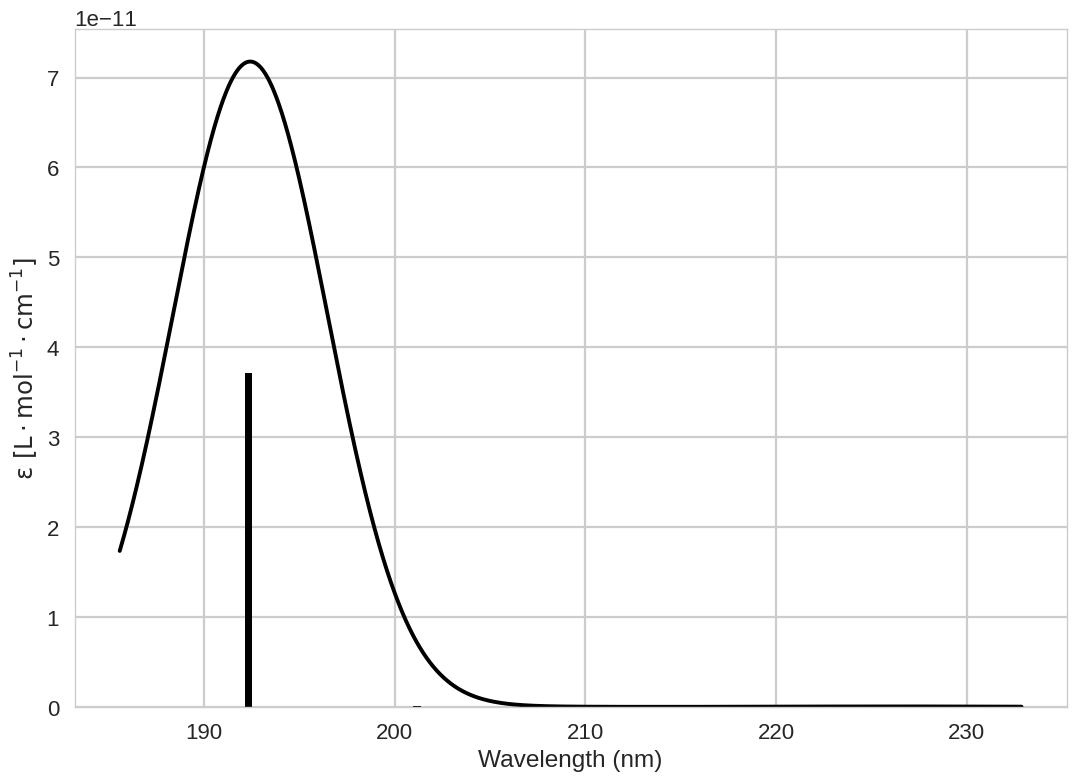

In [36]:
fs = 20

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(opa_spectrum['convolution']['x'],
        opa_spectrum['convolution']['y'],
        color='black')
ax.bar(opa_spectrum['sticks']['poles'],
       opa_spectrum['sticks']['residues'],
       color='black',
       width=0.4)

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$ \rm{\epsilon \ [L \cdot mol^{-1} \cdot cm^{-1}]} $')
fig.savefig('OPA.png', dpi=600, transparent=True)

##### 計算する励起状態の数を変えてOPAスペクトルを出力

In [37]:
num_states = [4, 8, 12, 20]
responses = []
for num in num_states:
    response = tdscf_excitations(wfn_td, states=num)
    responses.append(response)

In [38]:
spectrums = []
for response in responses:
    poles = [r['EXCITATION ENERGY'] for r in response]
    residues = [np.linalg.norm(r['ELECTRIC DIPOLE TRANSITION MOMENT (LEN)']) ** 2
                for r  in response]
    opa = spectrum(poles=poles,
                   residues=residues,
                   gamma=0.01,
                   out_units='nm')
    spectrums.append(opa)

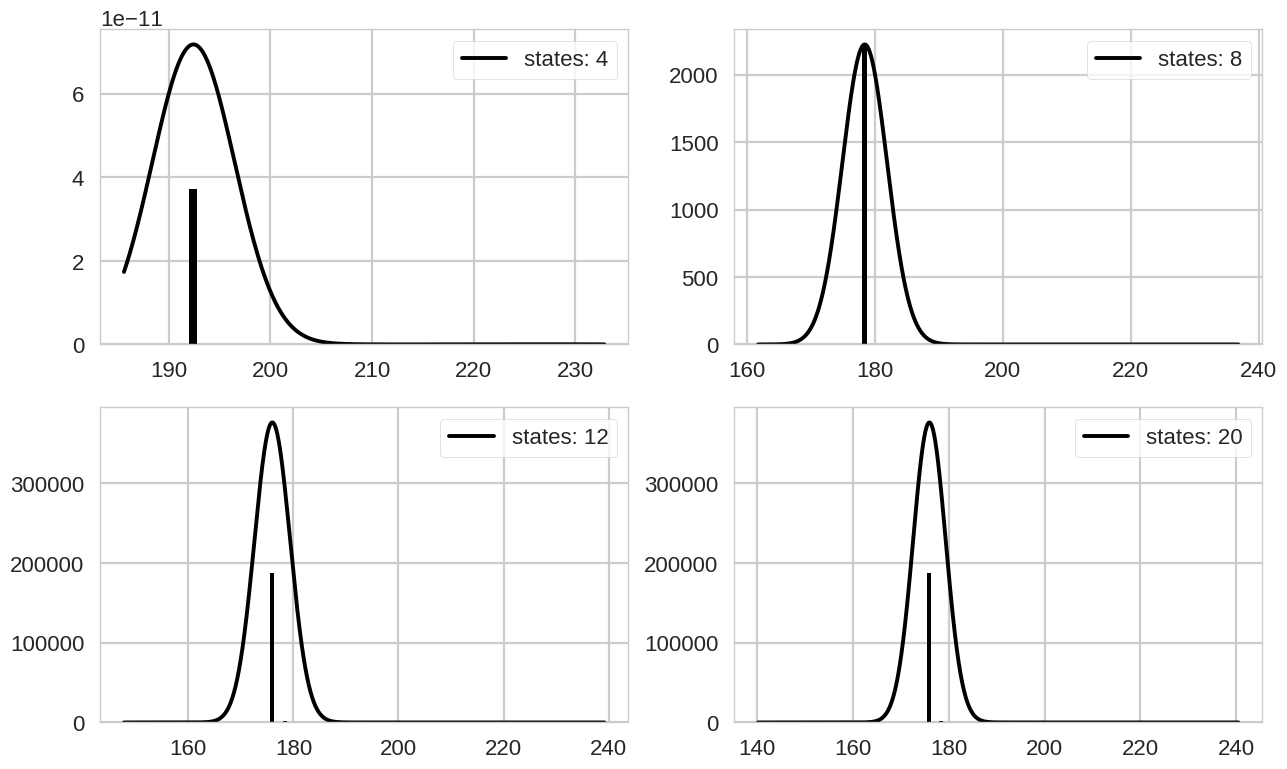

In [39]:
fig = plt.figure(figsize=(15, 9))

for i, (state, spectrum) in enumerate(zip(num_states, spectrums), start=1):
    ax = fig.add_subplot(2, 2, i)
    ax.plot(spectrum['convolution']['x'],
            spectrum['convolution']['y'],
            color='black',
            label=f'states: {state}')
    ax.bar(spectrum['sticks']['poles'],
           spectrum['sticks']['residues'],
           color='black')
    ax.legend(frameon=True)

#### ECDスペクトル

In [40]:
psi4.core.clean_options()

In [41]:
def get_ECD_spectrum(excited_states: list) -> list[np.ndarray]:
    """
    ECDスペクトル描画用データを作成する
    Args:
        excited_state: TD計算で得られた励起状態のデータ

    Returns:
        np.ndarray: ECDスペクトル用のX軸
        np.ndarray: ECDスペクトル用のY軸
        np.ndarray: 吸収波長
        np.ndarray: 強度

    """
    from psi4.driver.p4util import spectrum

    poles = [excited_state['EXCITATION ENERGY']
             for excited_state in excited_states]
    residues = [excited_state['ROTATORY STRENGTH (LEN)']
                for excited_state in excited_states]
    ecd_spectrum = spectrum(poles=poles,
                            residues=residues,
                            kind='ECD',
                            gamma=0.01,
                            out_units='nm')

    x_broaden = ecd_spectrum['convolution']['x']
    y_broaden = ecd_spectrum['convolution']['y']
    x = ecd_spectrum['sticks']['poles']
    y = ecd_spectrum['sticks']['residues']

    return [x_broaden, y_broaden, x, y]

##### S体

In [42]:
psi4.set_options({'SAVE_JK': True})
psi4.set_output_file('ECD_sample.log')

s_form = psi4.geometry('''
0 1
 C                 -0.45228216    0.14522821    0.00000000
 C                  0.94287784    0.14522821    0.00000000
 C                  1.64041584    1.35297921    0.00000000
 C                  0.94276184    2.56148821   -0.00119900
 C                 -0.45206316    2.56141021   -0.00167800
 C                 -1.14966416    1.35320421   -0.00068200
 H                 -1.00204116   -0.80708879    0.00045000
 H                  1.49238584   -0.80728479    0.00131500
 H                  1.49296184    3.51363121   -0.00125800
 H                 -1.00218516    3.51369121   -0.00263100
 H                 -2.24926816    1.35338721   -0.00086200
 C                  3.18041558    1.35309125    0.00088786
 H                  3.53672179    2.22050769    0.51618835
 C                  3.69458408    1.37096069   -1.45063253
 H                  4.76451996    1.35925545   -1.45018335
 H                  3.32868914    0.50953646   -1.96925494
 H                  3.34778992    2.25650596   -1.94098279
 O                  3.65678760    0.17734468    0.66088007
 H                  4.51713271    0.35378051    1.04853545
''')

In [43]:
# 構造最適化と振動数計算（計算に2時間程度かかる）
_, wfn_s = optfreq(s_form, 'cam-b3lyp/cc-pvdz')

Optimizer: Optimization complete!
 '392.5648' '422.6028' '478.9977' '539.9234' '614.0192']


In [44]:
print(get_freqs(wfn_s))

[   45.54073753   140.00835604   224.87691613   266.32486834
   275.06252475   316.44887396   392.56480778   422.60284058
   478.99766894   539.92336866   614.01924471   636.47268096
   727.53047705   774.68343239   791.60845373   880.18863614
   926.22859519   952.16279446  1009.96292262  1025.83380687
  1031.05578153  1035.53532755  1065.68905716  1101.76692324
  1115.42985190  1156.82178422  1172.78888044  1192.74724999
  1217.42736389  1253.09856095  1342.57549363  1353.35531375
  1365.54565019  1397.36488109  1422.42069486  1466.69721359
  1478.44671915  1499.66794987  1549.33480911  1676.21386285
  1699.41415462  2992.23218777  3047.89412871  3126.45082318
  3151.87590416  3182.46596510  3195.88283174  3207.13981679
  3221.06574195  3245.25105782  3835.07242426]


In [45]:
print(s_form.save_string_xyz())

0 1
 C   -1.914289594902   -1.037107366792    0.213196630407
 C   -0.521700038791   -1.056355688436    0.249244977440
 C    0.202359885346    0.128438061522    0.122685237368
 C   -0.489832375357    1.332134704647   -0.029009893110
 C   -1.880108527729    1.352172056835   -0.066401528121
 C   -2.598238862524    0.164184346676    0.053162910716
 H   -2.469854568457   -1.971605388091    0.315094931814
 H    0.021037250538   -1.990658217515    0.384959631328
 H    0.066075986650    2.269765104256   -0.112999770722
 H   -2.406504469993    2.301395077968   -0.183709566368
 H   -3.689400739187    0.177289970087    0.027304379719
 C    1.716525490684    0.121666903161    0.124676628635
 H    2.058136918639    0.949865674946    0.776784341285
 C    2.282222919242    0.339204898276   -1.276610981063
 H    3.384780715674    0.355004283698   -1.252337312007
 H    1.957049416804   -0.474288624208   -1.942035532020
 H    1.942420237843    1.294831867981   -1.701746342969
 O    2.152479702648   -1.1

In [46]:
show_3D(s_form)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

##### R体

In [47]:
r_form = psi4.geometry('''
0 1
 C                 -0.45228216    0.14522821    0.00000000
 C                  0.94287784    0.14522821    0.00000000
 C                  1.64041584    1.35297921    0.00000000
 C                  0.94276184    2.56148821    0.00119900
 C                 -0.45206316    2.56141021    0.00167800
 C                 -1.14966416    1.35320421    0.00068200
 H                 -1.00204116   -0.80708879   -0.00045000
 H                  1.49238584   -0.80728479   -0.00131500
 H                  1.49296184    3.51363121    0.00125800
 H                 -1.00218516    3.51369121    0.00263100
 H                 -2.24926816    1.35338721    0.00086200
 C                  3.18041558    1.35309125   -0.00088786
 H                  3.53672179    2.22050769   -0.51618835
 C                  3.69458408    1.37096069    1.45063253
 H                  4.76451996    1.35925545    1.45018335
 H                  3.32868914    0.50953646    1.96925494
 H                  3.34778992    2.25650596    1.94098279
 O                  3.65678760    0.17734468   -0.66088007
 H                  4.51713271    0.35378051   -1.04853545
''')

In [48]:
# 構造最適化・振動数計算（計算に2時間程度かかる）
_, wfn_r = optfreq(r_form, 'cam-b3lyp/cc-pvdz')

Optimizer: Optimization complete!
 '392.5627' '422.6031' '479.0027' '539.9236' '614.0221']


In [49]:
print(get_freqs(wfn_r))

[   45.54393917   140.00737119   224.87323407   266.32323455
   275.05812511   316.44791985   392.56268843   422.60305762
   479.00265590   539.92357587   614.02212341   636.47715645
   727.53034580   774.68140374   791.60747168   880.18818345
   926.22220374   952.16309633  1009.96252761  1025.84010284
  1031.05301825  1035.53084343  1065.68137163  1101.77195288
  1115.43058726  1156.82709011  1172.78718366  1192.74741287
  1217.42729303  1253.09141059  1342.57483284  1353.35507502
  1365.54640649  1397.36352392  1422.42021283  1466.69803720
  1478.44731666  1499.66667060  1549.33298718  1676.21613153
  1699.41337016  2992.22253754  3047.89928343  3126.44799036
  3151.87567134  3182.46808172  3195.88409401  3207.13521125
  3221.07259191  3245.24475798  3835.07552310]


In [50]:
print(r_form.save_string_xyz())

0 1
 C   -1.914289593162   -1.037107357721   -0.213196675956
 C   -0.521700041698   -1.056355670115   -0.249245045260
 C    0.202359888048    0.128438079943   -0.122685280946
 C   -0.489832371069    1.332134736258    0.029009899498
 C   -1.880108540085    1.352172062904    0.066401564110
 C   -2.598238862889    0.164184343753   -0.053162900274
 H   -2.469854559430   -1.971605378401   -0.315094991979
 H    0.021037247777   -1.990658191293   -0.384959719228
 H    0.066075995888    2.269765143100    0.112999815902
 H   -2.406504493848    2.301395078893    0.183709658891
 H   -3.689400733110    0.177289952938   -0.027304336466
 C    1.716525507573    0.121666868966   -0.124676630441
 H    2.058136980360    0.949865585645   -0.776784388258
 C    2.282222914132    0.339204948505    1.276610975544
 H    3.384780708382    0.355004330343    1.252337315028
 H    1.957049405377   -0.474288535775    1.942035566716
 H    1.942420229024    1.294831941848    1.701746281136
 O    2.152479697048   -1.1

In [51]:
show_3D(r_form)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [52]:
# TD-DFT計算
_, wfn_tds = psi4.energy('cam-b3lyp/aug-cc-pvdz',
                         molecule=s_form,
                         return_wfn=True)
excited_states_S = tdscf_excitations(wfn_tds, states=6)

In [53]:
_, wfn_tdr = psi4.energy('cam-b3lyp/aug-cc-pvdz',
                         molecule=r_form,
                         return_wfn=True)
excited_states_R = tdscf_excitations(wfn_tdr, states=6)

In [54]:
# ECDスペクトル
x_broaden_S, y_broaden_S, x_S, y_S = get_ECD_spectrum(excited_states_S)

In [55]:
x_broaden_R, y_broaden_R, x_R, y_R = get_ECD_spectrum(excited_states_R)

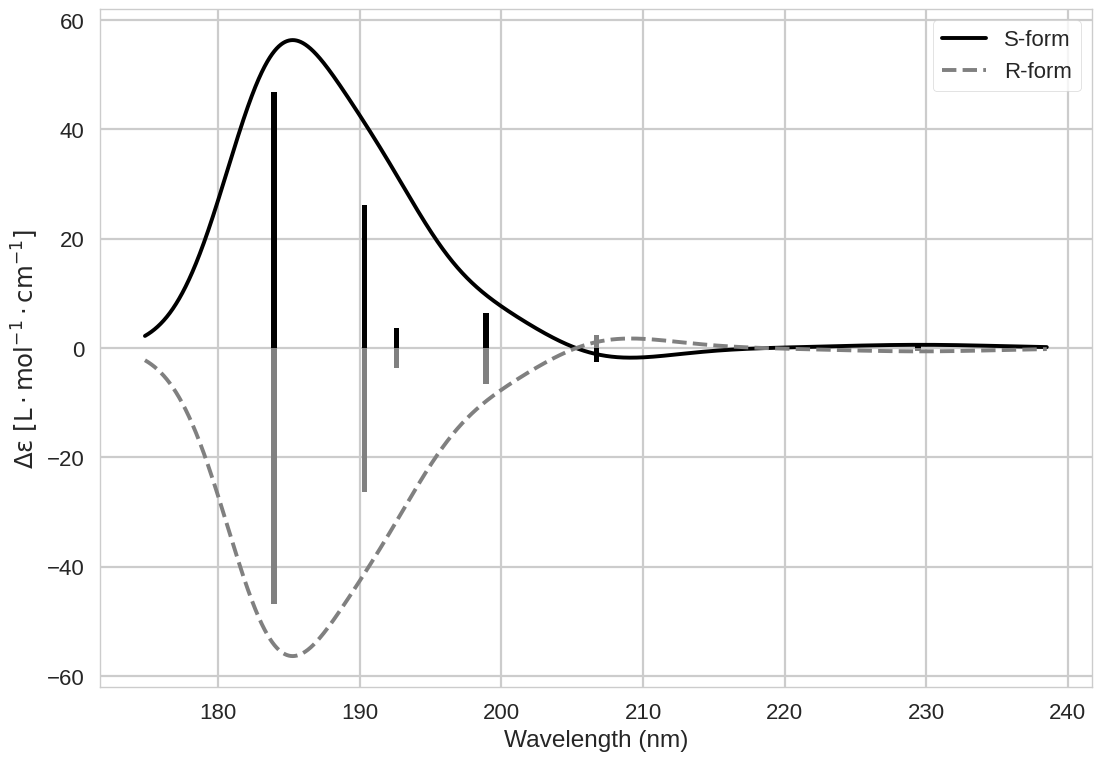

In [56]:
# 描画
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_broaden_S, y_broaden_S, color='black', label='S-form')
ax.bar(x_S, y_S, color='black', width=0.4)
ax.plot(x_broaden_R, y_broaden_R, '--', color='gray', label='R-form')
ax.bar(x_R, y_R, color='gray', width=0.4)
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$ \rm{\Delta \epsilon} \  [L \cdot mol^{-1} \cdot cm^{-1}]$')
ax.legend(frameon=True)
fig.savefig('ECD_RS.png', dpi=600, transparent=True)

#### 計算する励起状態の数を変化させてECDスペクトル

In [1]:
# 上の計算に引き続き下記の計算を行うとRAMが足りずクラッシュした。すぐに計算できるように，このセルで改めて関数など定義。
import os
import numpy as np
import psi4
from psi4.driver.procrouting.response.scf_response import tdscf_excitations

n_cpu = os.cpu_count()
ram = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / (1024 ** 3)
# 環境に応じて計算資源を設定
psi4.set_num_threads(n_cpu)
psi4.set_memory(f'{ram * 0.9: .0f}GB')


import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('seaborn-v0_8-poster')
mpl.style.use('seaborn-v0_8-whitegrid')


def get_ECD_spectrum(excited_states: list) -> list[np.ndarray]:
    """
    ECDスペクトル描画用データを作成する
    Args:
        excited_state: TD計算で得られた励起状態のデータ

    Returns:
        np.ndarray: ECDスペクトル用のX軸
        np.ndarray: ECDスペクトル用のY軸
        np.ndarray: 吸収波長
        np.ndarray: 強度

    """
    from psi4.driver.p4util import spectrum

    poles = [excited_state['EXCITATION ENERGY']
             for excited_state in excited_states]
    residues = [excited_state['ROTATORY STRENGTH (LEN)']
                for excited_state in excited_states]
    ecd_spectrum = spectrum(poles=poles,
                            residues=residues,
                            kind='ECD',
                            gamma=0.01,
                            out_units='nm')

    x_broaden = ecd_spectrum['convolution']['x']
    y_broaden = ecd_spectrum['convolution']['y']
    x = ecd_spectrum['sticks']['poles']
    y = ecd_spectrum['sticks']['residues']

    return [x_broaden, y_broaden, x, y]


psi4.set_options({'SAVE_JK': True})

# 上記セルで計算したS体の最適化構造をコピペ
s_form_optimized = psi4.geometry('''
0 1
 C   -1.914289594902   -1.037107366792    0.213196630407
 C   -0.521700038791   -1.056355688436    0.249244977440
 C    0.202359885346    0.128438061522    0.122685237368
 C   -0.489832375357    1.332134704647   -0.029009893110
 C   -1.880108527729    1.352172056835   -0.066401528121
 C   -2.598238862524    0.164184346676    0.053162910716
 H   -2.469854568457   -1.971605388091    0.315094931814
 H    0.021037250538   -1.990658217515    0.384959631328
 H    0.066075986650    2.269765104256   -0.112999770722
 H   -2.406504469993    2.301395077968   -0.183709566368
 H   -3.689400739187    0.177289970087    0.027304379719
 C    1.716525490684    0.121666903161    0.124676628635
 H    2.058136918639    0.949865674946    0.776784341285
 C    2.282222919242    0.339204898276   -1.276610981063
 H    3.384780715674    0.355004283698   -1.252337312007
 H    1.957049416804   -0.474288624208   -1.942035532020
 H    1.942420237843    1.294831867981   -1.701746342969
 O    2.152479702648   -1.119291042244    0.653722047958
 H    3.113144182905   -1.154439916964    0.565567606784
''')

In [2]:
psi4.set_output_file('ECD_comparison.log')

PosixPath('ECD_comparison.log')

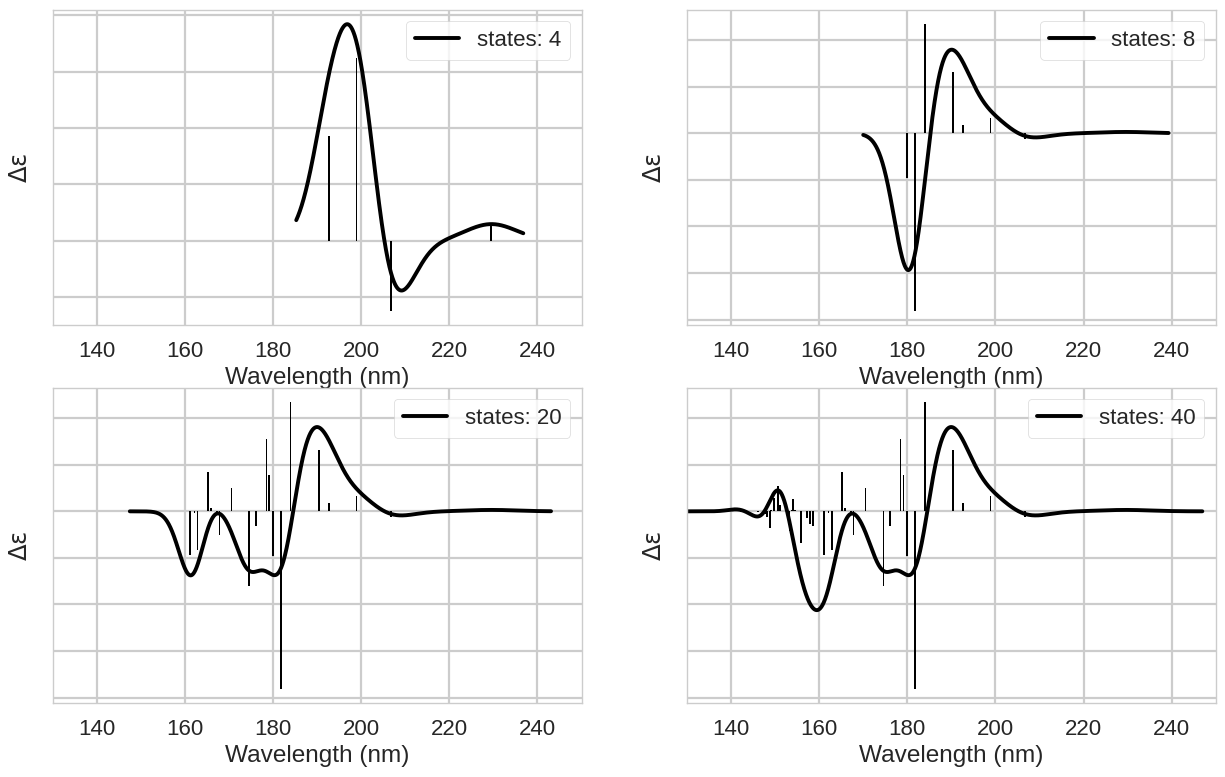

In [3]:
# 計算に3時間程度かかる
num_states = [4, 8, 20, 40]
states = []

fig = plt.figure(figsize=(15,9))
for i, num in enumerate(num_states, 1):
    _, wfn_td = psi4.energy('cam-b3lyp/aug-cc-pvdz',
                            molecule=s_form_optimized,
                            return_wfn=True)
    excited_states = tdscf_excitations(wfn_td, states=num)
    states.append(excited_states)
    x_broaden, y_broaden, x, y  = get_ECD_spectrum(excited_states)
    ax = fig.add_subplot(2, 2, i)
    ax.plot(x_broaden, y_broaden, color='black', label=f'states: {num}')
    ax.bar(x, y, color='black', width=0.4)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_xlim(130, 250)
    ax.set_xticks([140, 160, 180, 200, 220, 240])
    ax.set_xticklabels([140, 160, 180, 200, 220, 240])
    ax.set_yticklabels([])
    ax.set_ylabel(r'$ \rm{\Delta \epsilon} $')
    ax.legend(frameon=True)
fig.savefig('ECD_comparison.png', dpi=600, transparent=True)